# Hello · FWI — forward, backward, and a 5-line inversion loop

The smallest end-to-end SWEEP story. The same two-layer setup threads
through all three steps so the only thing that changes between them is
how you use the gradient.

1. **Forward** — fire one shot through the *truth* model, look at the gather
2. **Backward** — start from a homogeneous initial vp, run one `.backward()`, look at ∂loss / ∂vp
3. **FWI** — feed the gradient to `torch.optim.Adam` and watch the initial model relax onto the truth

No external data files, no Marmousi, no checkpointing tricks. Tested on CPU and CUDA.

## 1. Parameters

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt

from sweep.equations import Acoustic
from sweep.propagator.torch import PropTorch
from sweep.signal import ricker

shape = (96, 128)
dh    = 10.0
dt    = 0.002
nt    = 600
freq  = 10.0
delay = 0.12

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

device: cuda


## 2. Truth and initial velocity models

Two layers in the truth; the initial model is just a uniform 1500 m/s slab — so the only thing the inversion has to recover is the second layer.

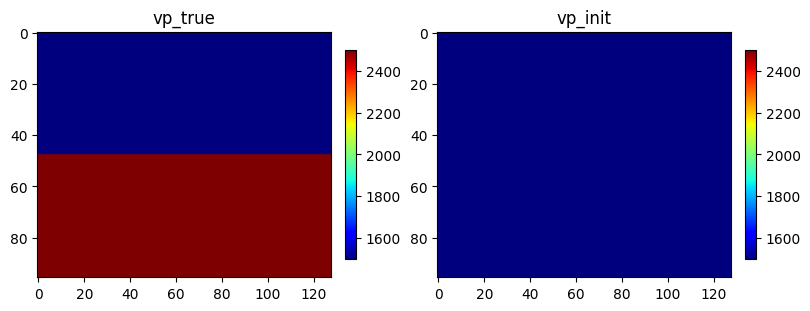

In [2]:
vp_true = np.full(shape, 1500.0, dtype=np.float32)
vp_true[shape[0] // 2:, :] = 2500.0
vp_init = np.full(shape, 1500.0, dtype=np.float32)

fig, axes = plt.subplots(1, 2, figsize=(8, 3), constrained_layout=True)
for ax, m, name in zip(axes, [vp_true, vp_init], ['vp_true', 'vp_init']):
    im = ax.imshow(m, cmap='jet', aspect='auto', vmin=1500, vmax=2500)
    ax.set_title(name)
    fig.colorbar(im, ax=ax, shrink=0.85)
plt.show()

## 3. Solver, source, receivers

`use_ckpt=False` keeps the full forward graph in memory so autograd has every time step to walk back through. For large models flip it back to `True` and SWEEP will checkpoint the forward for you.

In [3]:
equation = Acoustic(device=device)
solver   = PropTorch(equation, shape=shape, dh=dh, dt=dt, dev=device,
                     use_ckpt=False)

t = np.arange(nt, dtype=np.float32) * dt
wavelet = ricker(t - delay, f=freq).astype(np.float32)
sources = np.array([[shape[1] // 2, 2]], dtype=np.int64)
rec_x = np.linspace(0, shape[1] - 1, 64, dtype=np.int64)
receivers = np.stack([rec_x, np.full_like(rec_x, 4)], axis=1)[None]

### Aside · which sources and receivers does this equation accept?

`Acoustic` publishes a structured field table — query `eq.models` for the
expected model input order, `available_source_fields()` / `available_receiver_fields()`
for valid source / receiver options. See the
[Equations user guide](../../user-guide/equations/) for the full rundown.

In [4]:
print('models (input order matters!):')
for spec in equation.MODEL_SPECS:
    unit = f' [{spec.unit}]' if spec.unit else ''
    print(f'  - {spec.name:8s}{unit}  — {spec.description}')
print('defaults  :', equation.default_source_fields, '/', equation.default_receiver_fields)
print('receivers :')
for spec in equation.available_receiver_fields():
    print(f'  - {spec.name:8s} aliases={spec.aliases}  — {spec.description}')

models (input order matters!):
  - vp       [m/s]  — Acoustic P-wave velocity model.
defaults  : ['h1'] / ['h1']
receivers :
  - h1       aliases=('pressure', 'p')  — Primary acoustic pressure-like wavefield.


## 4. Forward — observed shot gather

The *Hello forward* step. One shot, one model, no autograd.

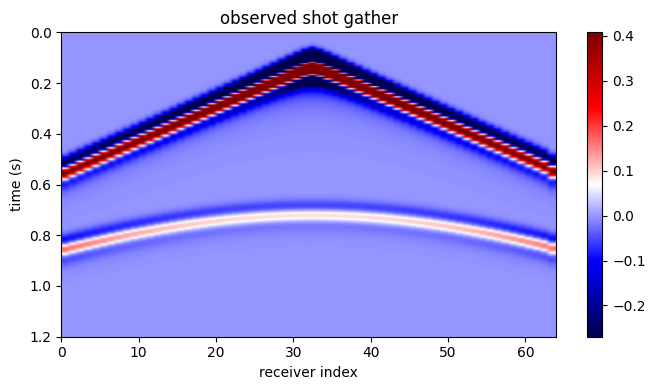

In [5]:
with torch.no_grad():
    obs = solver(wavelet, sources, receivers,
                 models=[torch.tensor(vp_true, device=device)])

gather = obs[0].squeeze().detach().cpu().numpy()
if gather.shape[0] != nt:
    gather = gather.T
vmin, vmax = np.percentile(gather, [2, 98])
plt.figure(figsize=(7, 4))
plt.imshow(gather, cmap='seismic', vmin=vmin, vmax=vmax, aspect='auto',
           extent=[0, receivers.shape[1], nt * dt, 0])
plt.xlabel('receiver index'); plt.ylabel('time (s)')
plt.title('observed shot gather')
plt.colorbar(); plt.tight_layout(); plt.show()

## 5. Backward — one velocity gradient

The *Hello backward* step. Switch on `requires_grad`, run the solver at the *initial* model, build an L2 misfit against the observed gather, and call `.backward()`.

loss: 6.94891357421875
grad min/max: -7.892603753134608e-05 8.705111395101994e-05


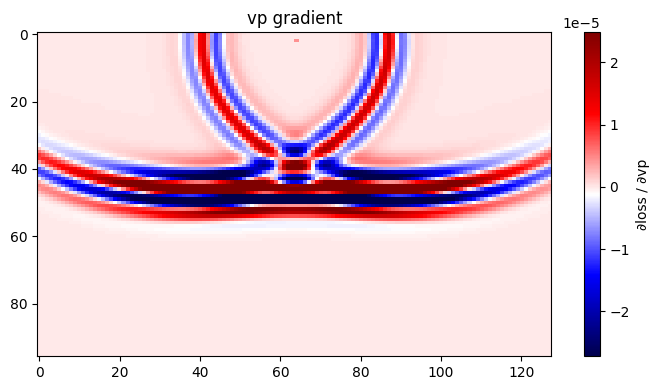

In [6]:
vp_t = torch.tensor(vp_init, device=device, requires_grad=True)
pred = solver(wavelet, sources, receivers, models=[vp_t])
loss = 0.5 * (pred - obs).pow(2).sum()
loss.backward()
print('loss:', float(loss.detach()))
print('grad min/max:', float(vp_t.grad.min()), float(vp_t.grad.max()))

g = vp_t.grad.detach().cpu().numpy()
vmin, vmax = np.percentile(g, [2, 98])
plt.figure(figsize=(7, 4))
plt.imshow(g, cmap='seismic', vmin=vmin, vmax=vmax, aspect='auto')
plt.title('vp gradient')
plt.colorbar(label='∂loss / ∂vp'); plt.tight_layout(); plt.show()

## 6. FWI — five lines of Adam

Plug the same gradient into an off-the-shelf optimizer and loop. That's it.

In [7]:
vp_t = torch.tensor(vp_init, device=device, requires_grad=True)
opt  = torch.optim.Adam([vp_t], lr=25.0)
n_iter = 40
losses = []
for k in range(n_iter):
    opt.zero_grad()
    pred = solver(wavelet, sources, receivers, models=[vp_t])
    l = 0.5 * (pred - obs).pow(2).sum()
    l.backward()
    opt.step()
    losses.append(float(l.detach()))
    if k % 5 == 0 or k == n_iter - 1:
        print(f'iter {k:3d}  loss {losses[-1]:.4e}')

iter   0  loss 6.9489e+00
iter   5  loss 3.8325e+00


iter  10  loss 1.7007e+00
iter  15  loss 1.3896e+00


iter  20  loss 1.1553e+00
iter  25  loss 8.9701e-01


iter  30  loss 6.5646e-01
iter  35  loss 3.9054e-01


iter  39  loss 3.5910e-01


## 7. Inverted vp and loss curve

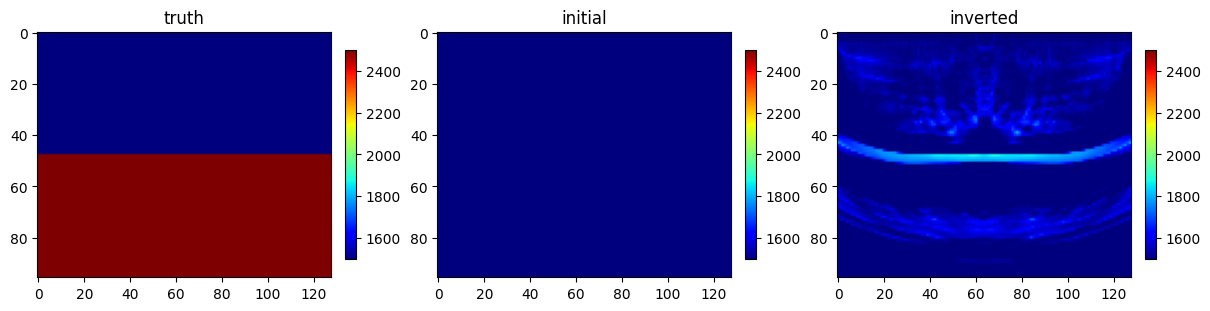

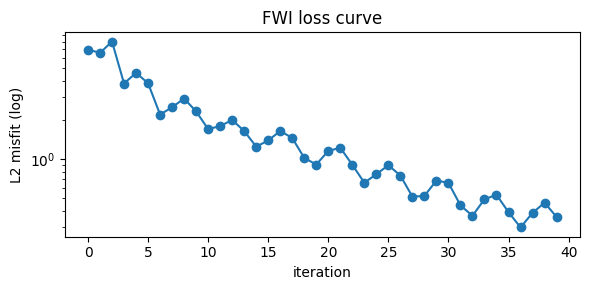

In [8]:
vp_inv = vp_t.detach().cpu().numpy()

fig, axes = plt.subplots(1, 3, figsize=(12, 3), constrained_layout=True)
for ax, m, name in zip(axes, [vp_true, vp_init, vp_inv], ['truth', 'initial', 'inverted']):
    im = ax.imshow(m, cmap='jet', aspect='auto', vmin=1500, vmax=2500)
    ax.set_title(name)
    fig.colorbar(im, ax=ax, shrink=0.85)
plt.show()

plt.figure(figsize=(6, 3))
plt.semilogy(losses, marker='o')
plt.xlabel('iteration'); plt.ylabel('L2 misfit (log)')
plt.title('FWI loss curve'); plt.tight_layout(); plt.show()

---

<p><strong>Download this notebook</strong> &mdash; <a href="00_hello_fwi.ipynb" download><code>00_hello_fwi.ipynb</code></a> &middot; or <a href="https://github.com/DeepWave-KAUST/sweep/blob/dev/examples/notebooks/00_hello_fwi.ipynb">view on GitHub</a></p>